# Fase 9 — ¿Le sirve a skip-gram la ventana ancha que a CBOW no le sirvió?

Las fases anteriores dejaron dos resultados que, juntos, plantean una pregunta
que ninguna de las dos podía contestar sola:

- **Fase 7**: a CBOW ensanchar la ventana **no** le sirve. De contexto 2 a 5 pasó
  de 41,3% a 42,3% en analogías, McNemar p = 0,66 — indistinguible de no haber
  cambiado nada. Y con dim 100 directamente empeoró.
- **Fase 8**: skip-gram y CBOW **empatan** a contexto 2. 40,2% contra 41,3%,
  p = 0,74, con 2,77× los pares y 2,09× el tiempo.

La pregunta que queda abierta: *¿el empate de la Fase 8 y la indiferencia de la
Fase 7 son el mismo hecho, o skip-gram sí aprovecha la ventana ancha?*

Hay una razón concreta para sospechar que sí. Cuando CBOW ensancha la ventana,
**promedia más palabras en un solo vector**: agregar vecinos lejanos diluye a los
cercanos, que son los que llevan la señal sintáctica. Skip-gram no promedia nada
—cada vecino es un ejemplo de entrenamiento propio—, así que un vecino lejano
*agrega* información en vez de tapar la del vecino cercano. Si ese mecanismo es
real, skip-gram debería ganar al pasar de contexto 2 a 5 más de lo que ganó CBOW.

Es una predicción falsable, y esta corrida la decide.

## El diseño: un 2×2 de arquitectura × contexto

| | contexto 2 | contexto 5 |
|---|---|---|
| **CBOW** | `piloto_5k_50_2` | `piloto_5k_50_5` |
| **skip-gram** | `piloto_sg_5k_50_2` | **`piloto_sg_5k_50_5`** ← la nueva |

Las cuatro comparten **todo** lo demás: el mismo `vocab.json` de 5.000 palabras
construido sobre el corpus completo (vía `vocab_from`), las mismas 2M de
oraciones de `muestra_2m.txt`, dim 50, 15 épocas, batch 512, lr 0,003, 10
negativos, semilla 42.

## Cómo se compara, y cómo no

Esto importa más acá que en cualquier fase anterior, porque **ninguna de las
cuatro corridas tiene la loss comparable con ninguna otra**:

- Entre contextos distintos la tarea cambia de dificultad (predecir desde 10
  palabras es más fácil que desde 4).
- Entre arquitecturas distintas no es ni siquiera la misma tarea: una adivina el
  centro desde su contexto, la otra un vecino desde el centro, sobre conjuntos de
  pares de tamaños distintos.

`comparable_loss` en `src/compare.py` incluye `arch` y `context_size`, y para
estas cuatro corridas devuelve **cuatro grupos distintos de uno**. O sea: la loss
sirve para verificar que cada modelo convergió, y para nada más.

**La comparación válida es la precisión en analogías**, y sobre todo `mcnemar`
pareado, que mira los ítems donde dos modelos discrepan en vez de enfrentar dos
porcentajes con sus intervalos.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np

from src.compare import collect, mcnemar
from src.config import load_config
from src.evaluate import load_embeddings, nearest_neighbors

plt.rcParams["figure.dpi"] = 110

CUATRO = ["piloto_5k_50_2", "piloto_5k_50_5",
          "piloto_sg_5k_50_2", "piloto_sg_5k_50_5"]
FILAS = {f["name"]: f for f in collect(CUATRO)}
CATEGORIAS = list(FILAS[CUATRO[0]]["categories"])

ETIQUETA = {
    "piloto_5k_50_2":    "CBOW · ctx 2",
    "piloto_5k_50_5":    "CBOW · ctx 5",
    "piloto_sg_5k_50_2": "skip-gram · ctx 2",
    "piloto_sg_5k_50_5": "skip-gram · ctx 5",
}
COLOR = {
    "piloto_5k_50_2":    "#7f8c9b",
    "piloto_5k_50_5":    "#2a6f97",
    "piloto_sg_5k_50_2": "#d99058",
    "piloto_sg_5k_50_5": "#b5361f",
}


def aciertos(nombre, categoria=None):
    """Resultado ítem por ítem, para las pruebas pareadas."""
    return [h for cat, *_, h in FILAS[nombre]["items"]
            if categoria is None or cat == categoria]


for nombre in CUATRO:
    f = FILAS[nombre]
    lo, hi = f["accuracy_ci"]
    print(f"{ETIQUETA[nombre]:<19} {f['arch']:<9} ctx {f['context_size']} | "
          f"analogías {f['accuracy']:5.1%} [{lo:.1%}, {hi:.1%}] | "
          f"{f['pairs_per_epoch']:>10,} pares/época | "
          f"{f['seconds_per_epoch_median']/60:5.1f} min/época")

CBOW · ctx 2        cbow      ctx 2 | analogías 41.3% [35.7%, 47.0%] |  5,009,035 pares/época |   2.6 min/época
CBOW · ctx 5        cbow      ctx 5 | analogías 42.3% [36.7%, 48.1%] |  5,009,035 pares/época |   2.7 min/época
skip-gram · ctx 2   skipgram  ctx 2 | analogías 40.2% [34.7%, 46.0%] | 13,865,356 pares/época |   5.4 min/época
skip-gram · ctx 5   skipgram  ctx 5 | analogías 36.7% [31.3%, 42.4%] | 24,968,216 pares/época |   7.0 min/época


---

## 9.1 El costo de ensanchar la ventana

Primero lo que cuesta, porque condiciona cómo leer cualquier ganancia.

CBOW genera **un par por token**, sin importar el ancho de la ventana: ensanchar
solo hace más largo el contexto de cada par. Skip-gram genera **un par por
vecino**, así que ensanchar la ventana multiplica la cantidad de pares.

¿Por cuánto exactamente? No se deduce del ancho de la ventana: el subsampling
acorta las oraciones, así que muchas ventanas quedan a medio llenar y el factor
real depende de cuánto. Hay que medirlo.

In [2]:
from src.config import corpus_path, vocab_path
from src.dataset import generate_pairs, generate_skipgram_pairs
from src.vocabulary import Vocabulary

CFG = load_config("configs/piloto_5k_50_2.yaml")
VOCAB = Vocabulary.load(vocab_path(CFG))
RUTA = corpus_path(CFG)
N = 50_000

print(f"medido sobre {N:,} oraciones de la muestra\n")
print(f"{'ctx':>4} {'pares CBOW':>12} {'pares SG':>12} {'factor':>8} "
      f"{'ancho medio':>12} {'techo':>7}")
medido = {}
for ctx in (2, 5):
    comunes = dict(limit=N, drop_unknown=True,
                   subsampling_threshold=CFG["subsampling_threshold"])
    n_cbow = ancho = 0
    for contexto, _target in generate_pairs(RUTA, VOCAB, ctx, **comunes):
        n_cbow += 1
        ancho += len(contexto)
    n_sg = sum(1 for _ in generate_skipgram_pairs(RUTA, VOCAB, ctx, **comunes))
    medido[ctx] = (n_cbow, n_sg, ancho / n_cbow)
    print(f"{ctx:>4} {n_cbow:>12,} {n_sg:>12,} {n_sg/n_cbow:>7.2f}x "
          f"{ancho/n_cbow:>12.2f} {2*ctx:>7}")

print()
print("El 'ancho medio' es cuántas palabras de contexto tiene un par en promedio,")
print("y el 'techo' es el máximo posible (2*ctx). La distancia entre ambos dice")
print("cuántas veces la ventana NO se llena.")

medido sobre 50,000 oraciones de la muestra

 ctx   pares CBOW     pares SG   factor  ancho medio   techo


   2      125,072      345,680    2.76x         2.76       4


   5      125,072      621,150    4.97x         4.97      10

El 'ancho medio' es cuántas palabras de contexto tiene un par en promedio,
y el 'techo' es el máximo posible (2*ctx). La distancia entre ambos dice
cuántas veces la ventana NO se llena.


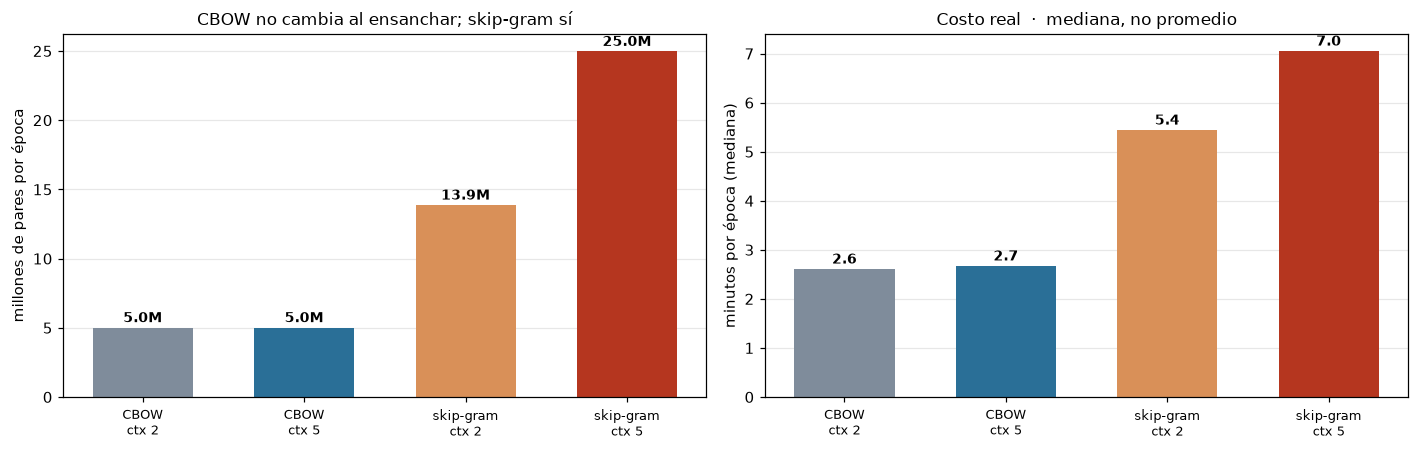

Se usa la MEDIANA de los tiempos por época y no el promedio porque
history.json guarda reloj de pared: si la máquina se suspende a mitad de
una época, esa época queda registrada con las horas de siesta adentro.
Ya pasó en este proyecto y llegó a invertir una conclusión de costo.

  CBOW · ctx 2        promedio   3.8 min | mediana   2.6 min  <- contaminada
  CBOW · ctx 5        promedio   2.7 min | mediana   2.7 min
  skip-gram · ctx 2   promedio  13.1 min | mediana   5.4 min  <- contaminada
  skip-gram · ctx 5   promedio   7.1 min | mediana   7.0 min


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# --- izquierda: pares por época, medidos en las corridas reales ---
ax = axes[0]
nombres = list(CUATRO)
pares = [FILAS[n]["pairs_per_epoch"] / 1e6 for n in nombres]
barras = ax.bar(range(4), pares, color=[COLOR[n] for n in nombres], width=0.62)
for i, v in enumerate(pares):
    ax.text(i, v + 0.4, f"{v:.1f}M", ha="center", fontweight="bold", fontsize=9)
ax.set_xticks(range(4))
ax.set_xticklabels([ETIQUETA[n].replace(" · ", "\n") for n in nombres], fontsize=8.5)
ax.set_ylabel("millones de pares por época")
ax.set_title("CBOW no cambia al ensanchar; skip-gram sí", fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# --- derecha: minutos por época (MEDIANA, no promedio) ---
ax = axes[1]
minutos = [FILAS[n]["seconds_per_epoch_median"] / 60 for n in nombres]
ax.bar(range(4), minutos, color=[COLOR[n] for n in nombres], width=0.62)
for i, v in enumerate(minutos):
    ax.text(i, v + 0.12, f"{v:.1f}", ha="center", fontweight="bold", fontsize=9)
ax.set_xticks(range(4))
ax.set_xticklabels([ETIQUETA[n].replace(" · ", "\n") for n in nombres], fontsize=8.5)
ax.set_ylabel("minutos por época (mediana)")
ax.set_title("Costo real  ·  mediana, no promedio", fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print("Se usa la MEDIANA de los tiempos por época y no el promedio porque")
print("history.json guarda reloj de pared: si la máquina se suspende a mitad de")
print("una época, esa época queda registrada con las horas de siesta adentro.")
print("Ya pasó en este proyecto y llegó a invertir una conclusión de costo.")
print()
for nombre in CUATRO:
    f = FILAS[nombre]
    prom = f["seconds_per_epoch"] / 60
    med = f["seconds_per_epoch_median"] / 60
    aviso = "  <- contaminada" if prom > med * 1.25 else ""
    print(f"  {ETIQUETA[nombre]:<19} promedio {prom:5.1f} min | mediana {med:5.1f} min{aviso}")

---

## 9.2 Analogías: la comparación que sí vale

Cuatro barras con su intervalo de Wilson, y el mismo dato como gráfico de
interacción. Si las dos líneas de la derecha fueran paralelas, ensanchar la
ventana le haría lo mismo a las dos arquitecturas. Si la de skip-gram sube más,
la predicción del encabezado se cumple.

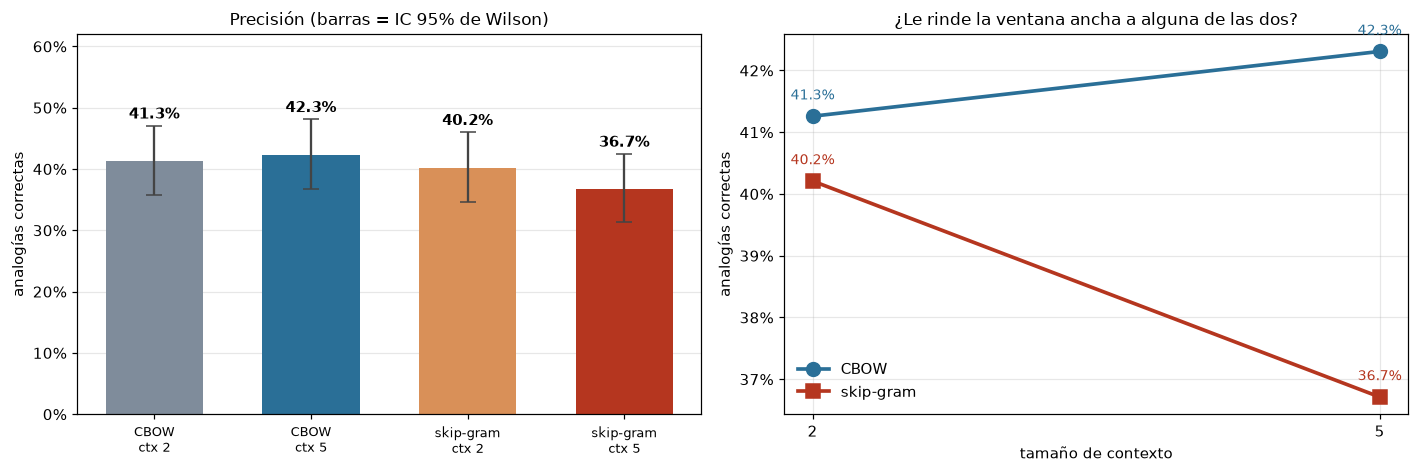

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# --- izquierda: precisión con IC de Wilson ---
ax = axes[0]
valores = [FILAS[n]["accuracy"] for n in CUATRO]
bajo = [FILAS[n]["accuracy"] - FILAS[n]["accuracy_ci"][0] for n in CUATRO]
alto = [FILAS[n]["accuracy_ci"][1] - FILAS[n]["accuracy"] for n in CUATRO]

ax.bar(range(4), valores, color=[COLOR[n] for n in CUATRO],
       yerr=[bajo, alto], capsize=5, ecolor="#444", width=0.62)
for i, v in enumerate(valores):
    ax.text(i, v + alto[i] + 0.012, f"{v:.1%}", ha="center", fontweight="bold")
ax.set_xticks(range(4))
ax.set_xticklabels([ETIQUETA[n].replace(" · ", "\n") for n in CUATRO], fontsize=8.5)
ax.set_ylabel("analogías correctas")
ax.set_title("Precisión (barras = IC 95% de Wilson)", fontsize=11)
ax.set_ylim(0, 0.62)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# --- derecha: interacción arquitectura x contexto ---
ax = axes[1]
series = [("CBOW", ["piloto_5k_50_2", "piloto_5k_50_5"], "#2a6f97", "o"),
          ("skip-gram", ["piloto_sg_5k_50_2", "piloto_sg_5k_50_5"], "#b5361f", "s")]
for etiqueta, par, color, marca in series:
    ys = [FILAS[n]["accuracy"] for n in par]
    ax.plot([2, 5], ys, marker=marca, markersize=9, linewidth=2.4,
            color=color, label=etiqueta)
    for x, y in zip((2, 5), ys):
        ax.annotate(f"{y:.1%}", (x, y), textcoords="offset points",
                    xytext=(0, 11), ha="center", fontsize=9, color=color)
ax.set_xticks([2, 5])
ax.set_xlabel("tamaño de contexto")
ax.set_ylabel("analogías correctas")
ax.set_title("¿Le rinde la ventana ancha a alguna de las dos?", fontsize=11)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(frameon=False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9.3 Las cuatro comparaciones pareadas

El 2×2 se lee con cuatro preguntas. Dos verticales (¿cambia la arquitectura?) y
dos horizontales (¿cambia el contexto?). Cada una con McNemar sobre los mismos
286 ítems.

In [5]:
def comparar(a, b, titulo, por_categoria=True):
    """McNemar global y por categoría entre dos corridas."""
    ga, gb = FILAS[a]["accuracy"], FILAS[b]["accuracy"]
    t = mcnemar(aciertos(a), aciertos(b))
    print(titulo)
    print(f"  {ETIQUETA[a]}  ->  {ETIQUETA[b]}")
    print(f"  GLOBAL  {ga:.1%} -> {gb:.1%}  ({(gb-ga)*100:+.1f} pp)   "
          f"solo A {t['solo_a']:>3} | solo B {t['solo_b']:>3} | p = {t['p_value']:.4f}"
          + ("  SIGNIFICATIVO" if t["p_value"] < 0.05 else ""))
    if por_categoria:
        for cat in CATEGORIAS:
            da, db = FILAS[a]["categories"][cat], FILAS[b]["categories"][cat]
            tc = mcnemar(aciertos(a, cat), aciertos(b, cat))
            marca = " *" if tc["p_value"] < 0.05 else ""
            print(f"    {cat:<24} {da['accuracy']:>7.1%} -> {db['accuracy']:>7.1%} "
                  f"({(db['accuracy']-da['accuracy'])*100:>+6.1f} pp)  "
                  f"p = {tc['p_value']:.4f}{marca}")
    print()
    return t


print("=" * 78)
print("EFECTO DEL CONTEXTO (la pregunta de esta fase)")
print("=" * 78)
ctx_cbow = comparar("piloto_5k_50_2", "piloto_5k_50_5",
                    "dentro de CBOW:")
ctx_sg = comparar("piloto_sg_5k_50_2", "piloto_sg_5k_50_5",
                  "dentro de skip-gram:")

print("=" * 78)
print("EFECTO DE LA ARQUITECTURA")
print("=" * 78)
arq_2 = comparar("piloto_5k_50_2", "piloto_sg_5k_50_2",
                 "con contexto 2 (esto ya lo midió la Fase 8):", por_categoria=False)
arq_5 = comparar("piloto_5k_50_5", "piloto_sg_5k_50_5",
                 "con contexto 5 (nuevo):", por_categoria=False)

EFECTO DEL CONTEXTO (la pregunta de esta fase)
dentro de CBOW:
  CBOW · ctx 2  ->  CBOW · ctx 5
  GLOBAL  41.3% -> 42.3%  (+1.0 pp)   solo A   9 | solo B  12 | p = 0.6636
    género                     61.1% ->   57.8% (  -3.3 pp)  p = 0.3750
    plural                     27.8% ->   31.1% (  +3.3 pp)  p = 0.5078
    verbo: presente → pasado   19.6% ->   19.6% (  +0.0 pp)  p = 1.0000
    país → gentilicio          76.7% ->   90.0% ( +13.3 pp)  p = 0.1250
    adjetivo → adverbio        20.0% ->   15.0% (  -5.0 pp)  p = 1.0000

dentro de skip-gram:
  skip-gram · ctx 2  ->  skip-gram · ctx 5
  GLOBAL  40.2% -> 36.7%  (-3.5 pp)   solo A  26 | solo B  16 | p = 0.1641
    género                     56.7% ->   54.4% (  -2.2 pp)  p = 0.7905
    plural                     26.7% ->   21.1% (  -5.6 pp)  p = 0.3323
    verbo: presente → pasado   19.6% ->   14.3% (  -5.4 pp)  p = 0.4531
    país → gentilicio          90.0% ->   86.7% (  -3.3 pp)  p = 1.0000
    adjetivo → adverbio        10.0% ->  

In [6]:
delta_cbow = FILAS["piloto_5k_50_5"]["accuracy"] - FILAS["piloto_5k_50_2"]["accuracy"]
delta_sg = FILAS["piloto_sg_5k_50_5"]["accuracy"] - FILAS["piloto_sg_5k_50_2"]["accuracy"]

print("LA PREDICCIÓN DEL ENCABEZADO, EN UN RENGLÓN")
print()
print(f"  ganancia de CBOW      al pasar de ctx 2 a 5:  {delta_cbow*100:+.1f} pp"
      f"   (p = {ctx_cbow['p_value']:.4f})")
print(f"  ganancia de skip-gram al pasar de ctx 2 a 5:  {delta_sg*100:+.1f} pp"
      f"   (p = {ctx_sg['p_value']:.4f})")
print()
veredicto = ("se cumple" if (delta_sg > delta_cbow and ctx_sg["p_value"] < 0.05)
             else "NO se cumple")
print(f"  -> la predicción {veredicto}.")

LA PREDICCIÓN DEL ENCABEZADO, EN UN RENGLÓN

  ganancia de CBOW      al pasar de ctx 2 a 5:  +1.0 pp   (p = 0.6636)
  ganancia de skip-gram al pasar de ctx 2 a 5:  -3.5 pp   (p = 0.1641)

  -> la predicción NO se cumple.


---

## 9.4 Dónde gana cada una

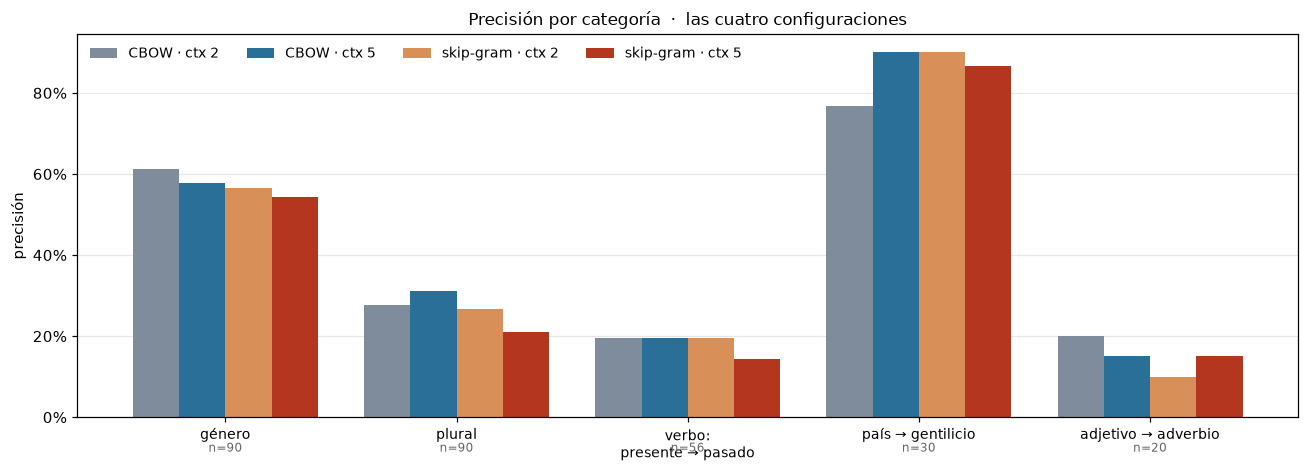

Recordatorio de ruido: 'adjetivo → adverbio' son 20 ítems, o sea que un
cambio de 10 puntos son 2 analogías. No conviene leer sus diferencias.


In [7]:
fig, ax = plt.subplots(figsize=(12, 4.4))

x = np.arange(len(CATEGORIAS))
ancho = 0.2
for i, nombre in enumerate(CUATRO):
    valores = [FILAS[nombre]["categories"][c]["accuracy"] for c in CATEGORIAS]
    ax.bar(x + (i - 1.5) * ancho, valores, ancho,
           label=ETIQUETA[nombre], color=COLOR[nombre])

ax.set_xticks(x)
ax.set_xticklabels([c.replace(": ", ":\n") for c in CATEGORIAS], fontsize=9)
ax.set_ylabel("precisión")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Precisión por categoría  ·  las cuatro configuraciones", fontsize=11)
ax.legend(frameon=False, ncol=4, fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
for xi, cat in zip(x, CATEGORIAS):
    ax.text(xi, -0.09, f"n={FILAS[CUATRO[0]]['categories'][cat]['evaluated']}",
            ha="center", fontsize=8, color="#666", transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()

print("Recordatorio de ruido: 'adjetivo → adverbio' son 20 ítems, o sea que un")
print("cambio de 10 puntos son 2 analogías. No conviene leer sus diferencias.")

---

## 9.5 Vecinos cercanos, lado a lado

El control cualitativo. La precisión en analogías es un número; esto es lo que se
ve al usar los embeddings.

In [8]:
CARGADOS = [(n, *load_embeddings(load_config(f"configs/{n}.yaml"))) for n in CUATRO]

for palabra in ["febrero", "mujer", "dijo", "ciudades", "italia", "rojo"]:
    print(f"\n{palabra}")
    for nombre, emb, voc in CARGADOS:
        vecinos = nearest_neighbors(palabra, emb, voc, k=6)
        print(f"  {ETIQUETA[nombre]:<19} " + ", ".join(w for w, _ in vecinos))


febrero
  CBOW · ctx 2        marzo, abril, octubre, mayo, julio, junio
  CBOW · ctx 5        marzo, abril, octubre, julio, junio, mayo
  skip-gram · ctx 2   octubre, marzo, abril, mayo, junio, septiembre
  skip-gram · ctx 5   octubre, abril, mayo, junio, marzo, julio

mujer
  CBOW · ctx 2        niña, infancia, niño, hermosa, vida, amiga
  CBOW · ctx 5        niña, infancia, niño, vida, mujeres, femenina
  skip-gram · ctx 2   niña, niño, infancia, mujeres, vida, niñas
  skip-gram · ctx 5   niña, niño, vida, mujeres, infancia, niñas

dijo
  CBOW · ctx 2        decía, sabía, dijeron, dije, llamó, dijiste
  CBOW · ctx 5        decía, sabía, dijeron, dije, quería, dijiste
  skip-gram · ctx 2   decía, sabía, pensaba, dijiste, quería, dijeron
  skip-gram · ctx 5   pensaba, sabía, decía, dijeron, fui, creía

ciudades
  CBOW · ctx 2        localidades, rutas, ciudad, provincias, calles, carreteras
  CBOW · ctx 5        localidades, rutas, provincias, ciudad, barrios, zonas
  skip-gram · ctx 

---

## 9.6 Las curvas de loss (y por qué no se comparan entre sí)

Las cuatro corridas tienen **cuatro tareas distintas**: dos arquitecturas × dos
tamaños de ventana. `comparable_loss` las pone en cuatro grupos separados de uno,
así que acá la loss sirve para una sola cosa: verificar que **cada** modelo
convergió. Comparar la altura de una curva contra otra no significa nada.

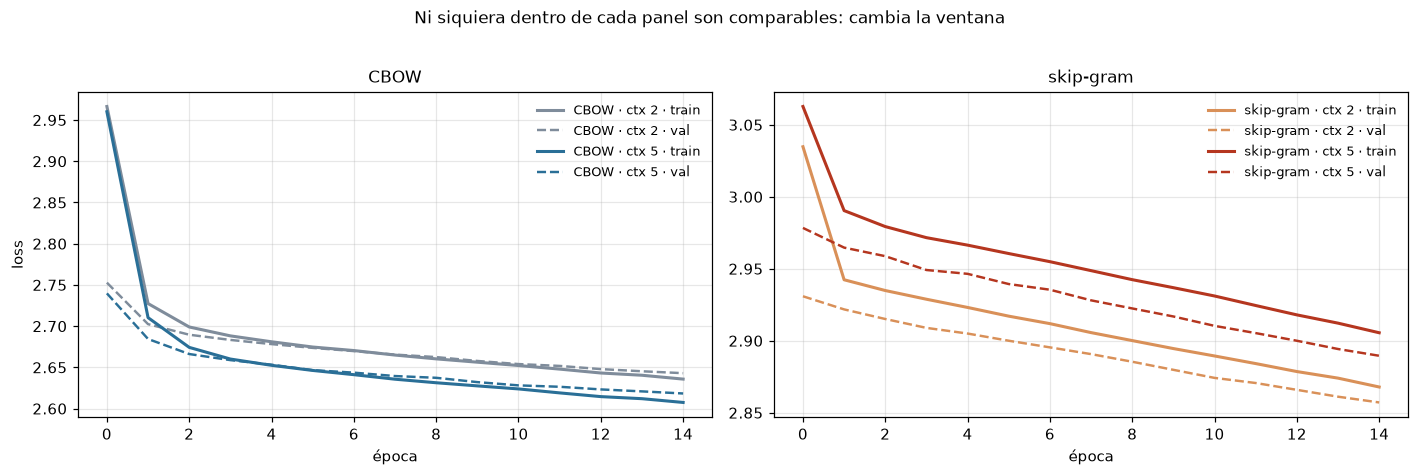

convergencia (train -> val en la última época):
  CBOW · ctx 2        train 2.6358 | val 2.6430 | brecha 0.0072
  CBOW · ctx 5        train 2.6075 | val 2.6183 | brecha 0.0109
  skip-gram · ctx 2   train 2.8679 | val 2.8572 | brecha 0.0107
  skip-gram · ctx 5   train 2.9056 | val 2.8896 | brecha 0.0160

Brechas chicas en las cuatro: ninguna sobreajustó. Es todo lo que se
puede concluir de estas curvas.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for ax, (titulo, par) in zip(axes, [
        ("CBOW", ["piloto_5k_50_2", "piloto_5k_50_5"]),
        ("skip-gram", ["piloto_sg_5k_50_2", "piloto_sg_5k_50_5"])]):
    for nombre in par:
        historia = FILAS[nombre]["history"]
        epocas = [r["epoch"] for r in historia]
        ax.plot(epocas, [r["train_loss"] for r in historia], linewidth=2,
                color=COLOR[nombre], label=f"{ETIQUETA[nombre]} · train")
        ax.plot(epocas, [r["val_loss"] for r in historia], linewidth=1.6,
                linestyle="--", color=COLOR[nombre],
                label=f"{ETIQUETA[nombre]} · val")
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("época")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, fontsize=8.5)

axes[0].set_ylabel("loss")
fig.suptitle("Ni siquiera dentro de cada panel son comparables: cambia la ventana",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print("convergencia (train -> val en la última época):")
for nombre in CUATRO:
    f = FILAS[nombre]
    print(f"  {ETIQUETA[nombre]:<19} train {f['train_loss']:.4f} | "
          f"val {f['val_loss']:.4f} | brecha {abs(f['val_loss']-f['train_loss']):.4f}")
print()
print("Brechas chicas en las cuatro: ninguna sobreajustó. Es todo lo que se")
print("puede concluir de estas curvas.")

---
# 9.7 Qué dice el experimento

## La predicción no se cumplió — y falló en la dirección opuesta

| | contexto 2 | contexto 5 | efecto de ensanchar |
|---|---|---|---|
| **CBOW** | 41,3% | 42,3% | +1,0 pp (p = 0,66) |
| **skip-gram** | 40,2% | 36,7% | **−3,5 pp** (p = 0,16) |

Esperábamos que skip-gram ganara *más* que CBOW al ensanchar la ventana. Lo que
pasó es que CBOW no se movió y **skip-gram empeoró**. La diferencia entre las dos
ganancias es de 4,5 puntos, en contra de la hipótesis.

## El único efecto de arquitectura significativo del proyecto, y va contra skip-gram

Con contexto 5, skip-gram queda **5,6 puntos por debajo** de CBOW:
IC 95% pareado [−10,2, −1,0], McNemar p = 0,026. Con contexto 2 el empate de la
Fase 8 se mantiene intacto (−1,0 pp, p = 0,74).

> **Con cautela.** Es la única comparación significativa entre cuatro de este
> notebook y ocho del proyecto. Con corrección de Bonferroni sobre estas cuatro,
> el umbral sería 0,0125 y p = 0,026 **no pasaría**. Es una señal consistente,
> no una conclusión cerrada.

## Por qué el razonamiento del encabezado estaba invertido

El argumento era: CBOW *diluye* los vecinos lejanos al promediarlos, mientras que
skip-gram los aprovecha como ejemplos propios, así que la ventana ancha debería
rendirle más a skip-gram.

Lo que ese argumento da por sentado es que **el vecino lejano trae señal útil**.
Si en realidad trae ruido para la tarea —y las relaciones morfológicas del
español viven en el vecino inmediato, no a cinco palabras de distancia—, entonces
promediar es una **defensa**, no una pérdida. CBOW diluye el ruido; skip-gram le
da peso completo, un ejemplo de entrenamiento por cada vecino lejano.

Eso predice que la caída se concentre en las relaciones de forma, y es lo que se
ve: **`plural` cae de 31,1% a 21,1%** (p = 0,035) — la única categoría con
diferencia individual significativa, y justamente la que depende del vecino
inmediato.

## El costo, que empeora el trato

Skip-gram a contexto 5 genera **24.968.216 pares por época: 4,98×** los de CBOW
—bastante más que el 2,77× de contexto 2, porque al ensanchar la ventana cada
token aporta más vecinos—. En tiempo: 7,0 min/época contra 2,7 de CBOW, es decir
**2,6× más caro para quedar 5,6 puntos más abajo**.

> Nota sobre cómo se midió: el promedio de `piloto_sg_5k_50_2` da 13,1 min/época
> y su mediana 5,4. Esa brecha es una suspensión de la máquina registrada dentro
> de una época, no cómputo. Por eso el costo se lee siempre con la **mediana**.

## Lo que este resultado no dice

La advertencia de la Fase 8 sigue en pie y es importante para no sobreinterpretar:
con vocabulario de 5.000 sobre 2.028M de tokens **no hay palabras raras** —la
última del vocabulario, `cercana`, aparece 33.838 veces—, así que el mecanismo por
el cual skip-gram suele ganar en la literatura no tiene dónde actuar.

Lo que se midió es que **a esta escala y con esta ventana, skip-gram no conviene**.
No que skip-gram sea peor en general. La prueba que faltaría pide vocabulario 20k+
sobre el corpus completo, donde sí existan palabras poco frecuentes.

## Resumen operativo

- Ensanchar la ventana **no le sirve a ninguna de las dos** arquitecturas. A CBOW
  le da igual; a skip-gram lo perjudica.
- Entre CBOW y skip-gram, a esta escala: **CBOW**, por costo si no por precisión.
- La configuración recomendada del proyecto sigue siendo `piloto_5k_100_2`
  (dim 100, contexto 2, CBOW, 54,2%), que ninguna corrida de esta fase toca.